In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import os

In [2]:
PREPATH = '../Data/PreProcessed/'
POSPATH = '../Data/PosProcessed/'
CLASSPATH = '../Data/Classification/'

---

#### **01 ) - Instânciando Dados**

---

---

##### A ) Instânciando PosDatasetsClean

In [3]:
df_PosDatasetsClean = pd.read_csv(os.path.join(POSPATH, 'PosDatasetsClean.csv'))
df_PosDatasetsClean.head()

,id,Dataset_Title,URL,is_encrypted,Columns,Columns_Count,Numeric_Cols,Categorical_Cols,Memory_Usage_MB
0,CRED-002,South German Credit,https://www.kaggle.com/datasets/sid321axn/sout...,0,"['status', 'duration', 'credit_history', 'purp...",21,3,18,"0,26"
1,CRED-004,Australian Credit Approval,https://www.kaggle.com/datasets/bfueojjsjdjsl/...,1,"['CustomerID', 'A1', 'A2', 'A3', 'A4', 'A5', '...",16,16,0,"0,03"
2,CRED-005,Japanese Credit Screening,https://www.kaggle.com/datasets/xiangshan1989/...,1,"['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8...",16,7,9,"0,03"
3,CRED-007,Polish Companies Bankruptcy,https://www.kaggle.com/datasets/stealthtechnol...,1,"['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8...",66,66,0,"20,47"
4,CRED-008,Qualitative Bankruptcy,https://www.kaggle.com/datasets/jagadeesh23/qu...,1,"['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'Class']",7,0,7,"0,01"


---

##### B ) Instânciando MacroTaxonomyClassification

In [4]:
df_MacroTC = pd.read_csv(os.path.join(CLASSPATH, 'MacroTaxonomyClassification.csv'))
df_MacroTC = df_MacroTC[['id', 'Col', 'Col_Standardized']]
df_MacroTC.head()

,id,Col,Col_Standardized
0,CRED-002,status,INSTITUTIONAL and FINANCIAL
1,CRED-002,duration,INSTITUTIONAL and FINANCIAL
2,CRED-002,credit_history,INSTITUTIONAL and FINANCIAL
3,CRED-002,purpose,INSTITUTIONAL and FINANCIAL
4,CRED-002,amount,INSTITUTIONAL and FINANCIAL


---

##### C ) Instânciando MicroTaxonomyClassification

In [5]:
df_MicroTC = pd.read_csv(os.path.join(CLASSPATH, 'MicroTaxonomyClassificationAdt.csv'))
df_MicroTC = df_MicroTC[['variavel_original', 'conceito_padronizado', 'macro_categoria']]
df_MicroTC.head()

,variavel_original,conceito_padronizado,macro_categoria
0,status,loan_status,INSTITUTIONAL and FINANCIAL
1,duration,payment_term_duration,INSTITUTIONAL and FINANCIAL
2,credit_history,credit_rating,INSTITUTIONAL and FINANCIAL
3,purpose,loan_purpose,INSTITUTIONAL and FINANCIAL
4,amount,loan_amount,INSTITUTIONAL and FINANCIAL


---

#### **02 ) - Gráficos Simples**

---

---

##### A ) Proporção de Datasets Criptografados

- <p align="justify">O gráfico mostra como as bases de crédito se dividem em relação à privacidade. A fatia de dados abertos (is_encrypted == 0) mantém o nome original das variáveis, o que facilita muito o nosso trabalho com processamento de linguagem natural. Já o grupo de dados anonimizados (is_encrypted == 1) passou por um mascaramento para proteger informações sensíveis.'</p>

In [6]:
df_encrypted = df_PosDatasetsClean['is_encrypted'].value_counts(normalize=True).reset_index().copy()
df_encrypted

,is_encrypted,proportion
0,0,0.745098
1,1,0.254902


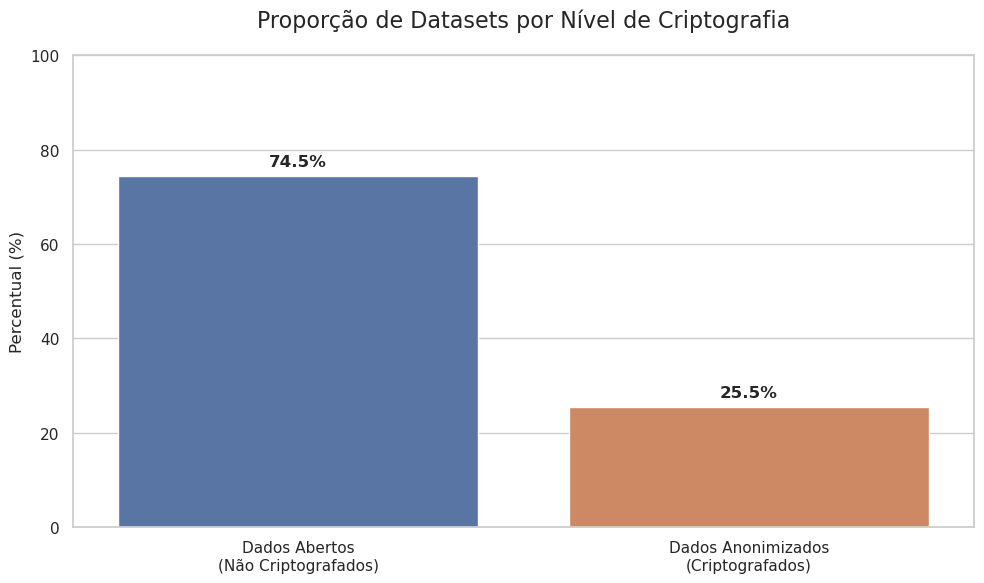

In [7]:
df_plot = df_encrypted.copy()
df_plot.columns = ['is_encrypted', 'proportion']
df_plot['Percentage'] = df_plot['proportion'] * 100
mapeamento = {0: 'Dados Abertos\n(Não Criptografados)', 1: 'Dados Anonimizados\n(Criptografados)'}
df_plot['Status'] = df_plot['is_encrypted'].map(mapeamento)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Status', y='Percentage', hue='Status',data=df_plot, palette=['#4C72B0', '#DD8452'], legend=False,ax=ax)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height + 1.5),ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Proporção de Datasets por Nível de Criptografia', fontsize=16, pad=20)
ax.set_ylabel('Percentual (%)', fontsize=12)
ax.set_xlabel('')
ax.set_ylim(0, 100) 
plt.tight_layout()
plt.show()

---

##### B ) Percentual das Macrocategorias para as Variáveis

- <p align="justify">Os gráficos apresentam a distribuição percentual das categorias macro identificadas no processo de classificação. O primeiro gráfico (G1) detalha a composição completa da base, incluindo o volume de dados ainda não categorizados. Já o segundo gráfico (G2) oferece uma visão refinada, removendo a classe "UNCLASSIFIED" para evidenciar a proporção relativa entre as categorias de crédito efetivamente rotuladas, permitindo uma análise mais clara da relevância de cada segmento no modelo.</p>

In [8]:
df_MacroTC_value_counts = df_MacroTC['Col_Standardized'].value_counts(normalize=True).reset_index().copy()
df_MacroTC_value_counts

,Col_Standardized,proportion
0,INSTITUTIONAL and FINANCIAL,0.532366
1,UNCLASSIFIED,0.237723
2,SOCIOECONOMIC,0.113839
3,ALTERNATIVE,0.064732
4,DEMOGRAPHIC,0.037946
5,EDUCATIONAL,0.005580
6,"VALUES, ATTITUDES and BEHAVIORAL",0.005580
7,MACROECONOMIC,0.002232


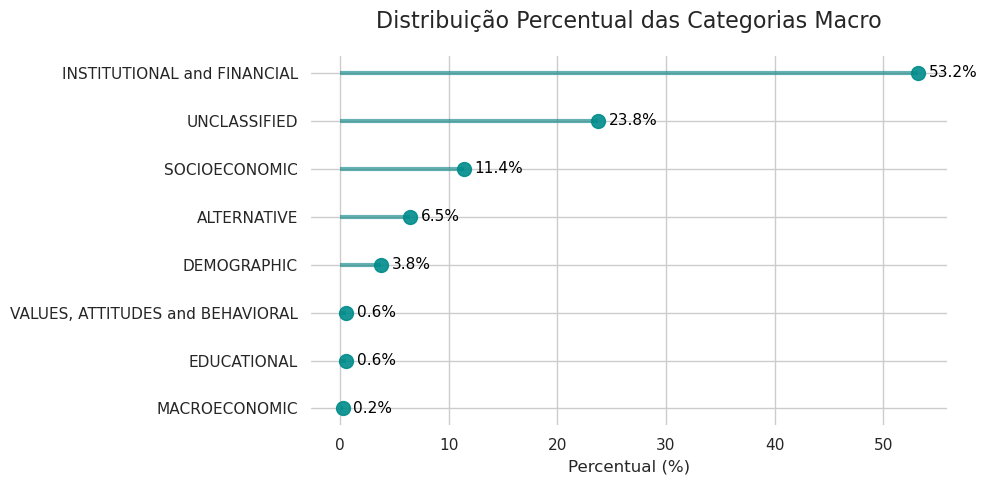

In [9]:
df_MacroTC_percent = df_MacroTC['Col_Standardized'].value_counts(normalize=True) * 100
df_plot = df_MacroTC_percent.reset_index()
df_plot.columns = ['Macro Category', 'Percentage']
df_plot = df_plot.sort_values(by='Percentage', ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hlines(y=df_plot['Macro Category'], xmin=0, xmax=df_plot['Percentage'], color='teal', alpha=0.6, linewidth=3)
ax.plot(df_plot['Percentage'], df_plot['Macro Category'], "o", markersize=10, color='darkcyan', alpha=0.9)
for i, v in enumerate(df_plot['Percentage']):
    ax.text(v + 1, i, f'{v:.1f}%', color='black', va='center', fontsize=11)
ax.set_title('Distribuição Percentual das Categorias Macro', fontsize=16, pad=20)
ax.set_xlabel('Percentual (%)', fontsize=12)
ax.set_ylabel('')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [10]:
df_split_MacroTC_value_counts = df_MacroTC[(df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED')]['Col_Standardized'].value_counts(normalize=True).reset_index().copy()
df_split_MacroTC_value_counts

,Col_Standardized,proportion
0,INSTITUTIONAL and FINANCIAL,0.698389
1,SOCIOECONOMIC,0.149341
2,ALTERNATIVE,0.084919
3,DEMOGRAPHIC,0.049780
4,EDUCATIONAL,0.007321
5,"VALUES, ATTITUDES and BEHAVIORAL",0.007321
6,MACROECONOMIC,0.002928


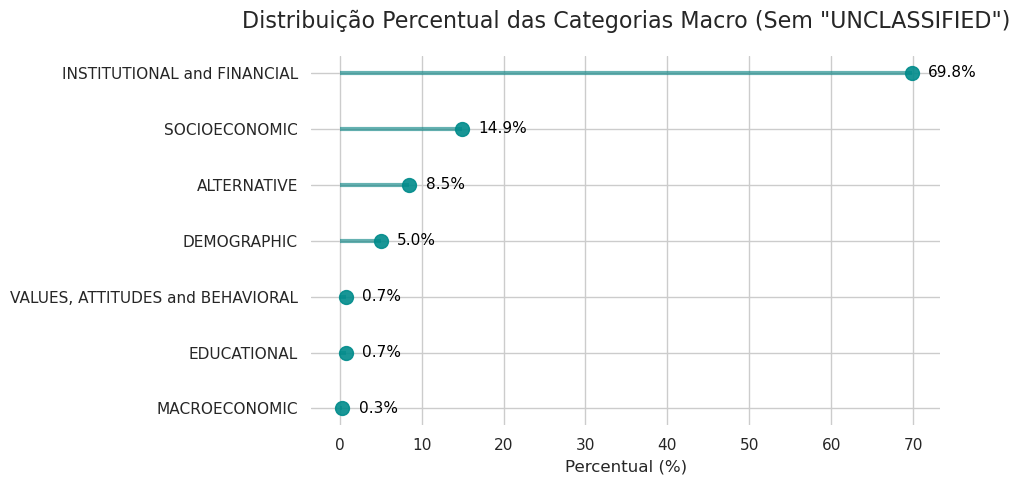

In [11]:
df_plot = df_split_MacroTC_value_counts.copy()
df_plot['Percentage'] = df_plot['proportion'] * 100
df_plot = df_plot.sort_values(by='Percentage', ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hlines(y=df_plot['Col_Standardized'], xmin=0, xmax=df_plot['Percentage'], color='teal', alpha=0.6, linewidth=3)
ax.plot(df_plot['Percentage'], df_plot['Col_Standardized'], "o", markersize=10, color='darkcyan', alpha=0.9)
for i, v in enumerate(df_plot['Percentage']):
    ax.text(v + 2, i, f'{v:.1f}%', color='black', va='center', fontsize=11)
ax.set_title('Distribuição Percentual das Categorias Macro (Sem "UNCLASSIFIED")', fontsize=16, pad=20)
ax.set_xlabel('Percentual (%)', fontsize=12)
ax.set_ylabel('')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

---

##### C ) Percentual das Macrocategorias para os Datasets


- <p align="justify">Presença das categorias nos conjuntos de dados analisados. Este gráfico mostra o percentual de bases de dados que possuem pelo menos uma informação referente a cada tema principal. É uma forma direta de observar quais categorias são mais comuns ou mais raras dentro do conjunto total de arquivos coletados para a pesquisa.<p>

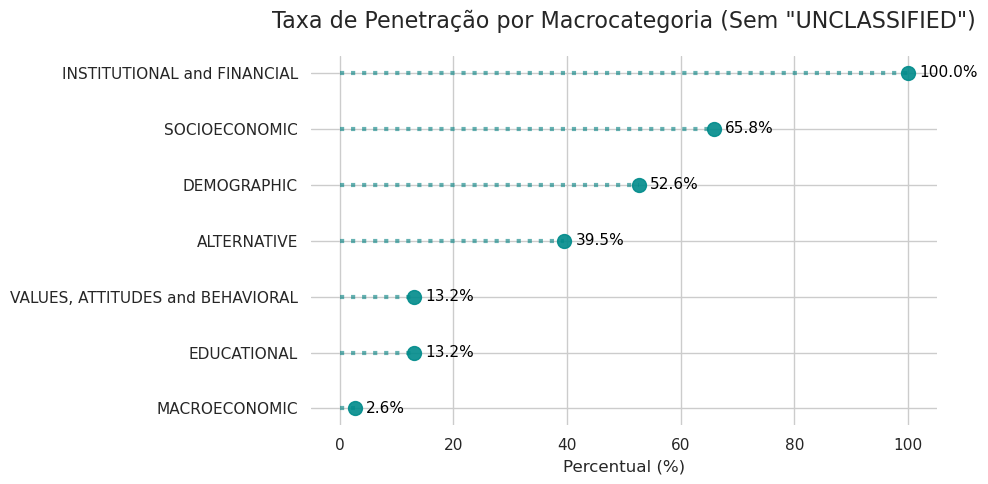

In [12]:
df_valid_macro = df_MacroTC[df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED'].copy()
df_crosstab = pd.crosstab(df_valid_macro['id'], df_valid_macro['Col_Standardized']).fillna(0)
df_presenca = (df_crosstab > 0).mean() * 100
df_presenca_plot = df_presenca.reset_index()
df_presenca_plot.columns = ['Macro_Categoria', 'Percentual_Presenca']
df_presenca_plot = df_presenca_plot.sort_values(by='Percentual_Presenca', ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hlines(y=df_presenca_plot['Macro_Categoria'], xmin=0, xmax=df_presenca_plot['Percentual_Presenca'], color='teal', alpha=0.6, linewidth=3, linestyles='dotted')
ax.plot(df_presenca_plot['Percentual_Presenca'], df_presenca_plot['Macro_Categoria'], "o", markersize=10, color='darkcyan', alpha=0.9)
for i, v in enumerate(df_presenca_plot['Percentual_Presenca']):
    ax.text(v + 2, i, f'{v:.1f}%', color='black', va='center', fontsize=11)
ax.set_title('Taxa de Penetração por Macrocategoria (Sem "UNCLASSIFIED")', fontsize=16, pad=20)
ax.set_xlabel('Percentual (%)', fontsize=12)
ax.set_ylabel('')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

---

##### E ) Principais Variáveis de Crédito

- <p align="justify">Ranking dos dez termos mais comuns após a limpeza e organização dos dados. Este gráfico destaca quais são as informações que mais se repetem entre todos os conjuntos de dados analisados. É uma forma de visualizar quais são os conceitos fundamentais e mais frequentes que compõem a estrutura dos registros de crédito estudados.</p>

In [14]:
df_MicroTC_value_counts = df_MicroTC['conceito_padronizado'].value_counts().reset_index()
df_MicroTC_value_counts.head(10)

,conceito_padronizado,count
0,monthly_income,26
1,loan_amount,25
2,age,23
3,asset_ownership,20
4,credit_score,14
5,transaction_amount,14
6,loan_purpose,13
7,geographic_region,13
8,credit_rating,12
9,employment_status,12


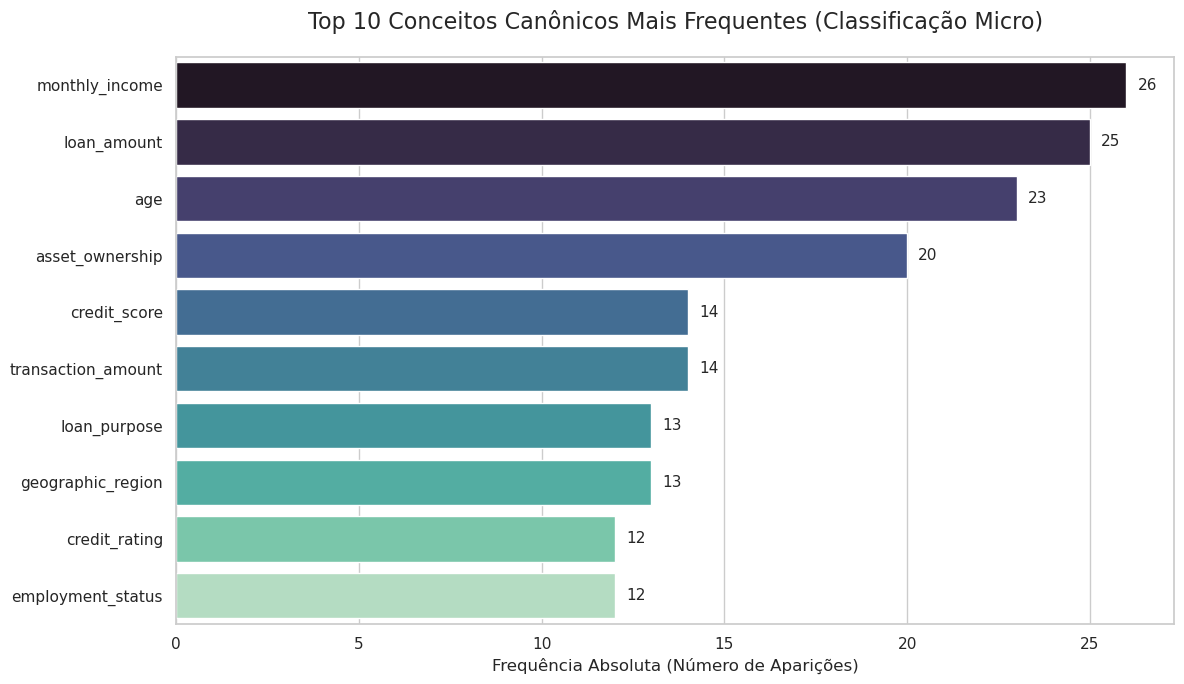

In [15]:
df_MicroTC_value_counts = df_MicroTC['conceito_padronizado'].value_counts().reset_index()
df_MicroTC_value_counts.columns = ['conceito_padronizado', 'count']
df_top10 = df_MicroTC_value_counts.head(10)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='count', y='conceito_padronizado', hue='conceito_padronizado', data=df_top10, palette='mako', legend=False,               ax=ax)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', (width + 0.3, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11)
ax.set_title('Top 10 Conceitos Canônicos Mais Frequentes (Classificação Micro)', fontsize=16, pad=20)
ax.set_xlabel('Frequência Absoluta (Número de Aparições)', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---

##### E ) Percentual das Microcategorias para os Datasets

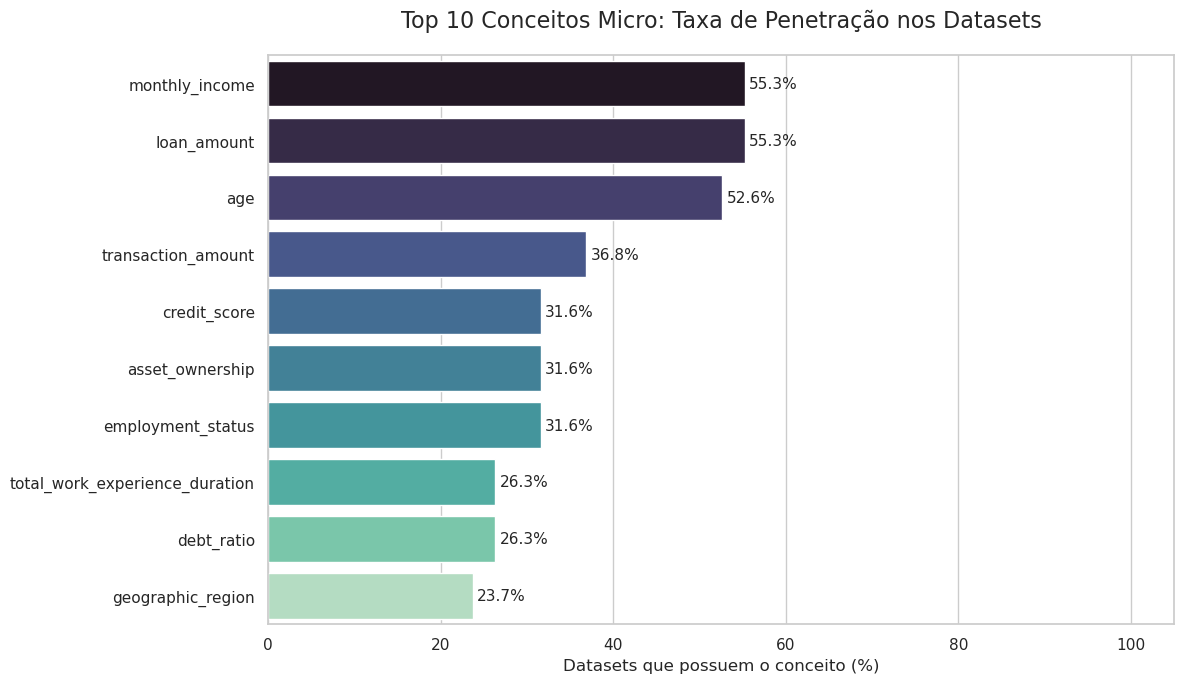

In [16]:
df_Micro_Cross = pd.merge(df_MacroTC[['id', 'Col']], df_MicroTC, left_on='Col', right_on='variavel_original', how='inner')
df_crosstab_micro = pd.crosstab(df_Micro_Cross['id'], df_Micro_Cross['conceito_padronizado']).fillna(0)
df_presenca_micro = (df_crosstab_micro > 0).mean() * 100
df_presenca_micro_plot = df_presenca_micro.reset_index()
df_presenca_micro_plot.columns = ['Conceito_Micro', 'Percentual_Presenca']
df_top10_presenca = df_presenca_micro_plot.sort_values(by='Percentual_Presenca', ascending=False).head(10)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Percentual_Presenca', y='Conceito_Micro', hue='Conceito_Micro',data=df_top10_presenca, palette='mako', legend=False,ax=ax)
ax.set_title('Top 10 Conceitos Micro: Taxa de Penetração nos Datasets', fontsize=16, pad=20)
ax.set_xlabel('Datasets que possuem o conceito (%)', fontsize=12)
ax.set_ylabel('')
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', (width + 0.5, p.get_y() + p.get_height() / 2),ha='left', va='center', fontsize=11)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

---

##### F ) ...

In [17]:
df_stats = df_PosDatasetsClean.copy()
df_stats['Numeric_Cols'] = df_stats['Numeric_Cols'].fillna(0)
df_stats['Categorical_Cols'] = df_stats['Categorical_Cols'].fillna(0)
df_stats['Total_Cols'] = df_stats['Numeric_Cols'] + df_stats['Categorical_Cols']
df_stats['Perc_Numeric'] = (df_stats['Numeric_Cols'] / df_stats['Total_Cols']) * 100
df_stats['Perc_Categorical'] = (df_stats['Categorical_Cols'] / df_stats['Total_Cols']) * 100
resumo_estatistico = df_stats[['Perc_Numeric', 'Perc_Categorical']].describe()
print("--- ANÁLISE DESCRITIVA DA MORFOLOGIA ---")
print(resumo_estatistico)
print("-" * 40)

--- ANÁLISE DESCRITIVA DA MORFOLOGIA ---
       Perc_Numeric  Perc_Categorical
count     51.000000         51.000000
mean      66.585813         33.414187
std       27.186458         27.186458
min        0.000000          0.000000
25%       45.625000          9.307359
50%       71.428571         28.571429
75%       90.692641         54.375000
max      100.000000        100.000000
----------------------------------------


---

#### **03 ) - Gráficos Avançados**

---

---

##### A ) Gráfico de Dispersão com Histogramas Marginais

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

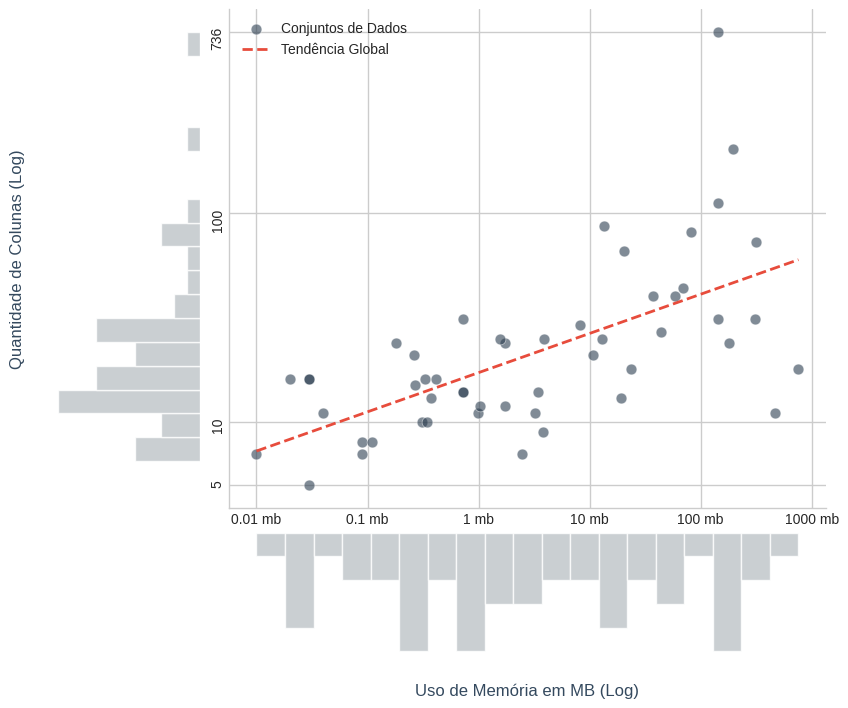

In [19]:
df = df_PosDatasetsClean.copy()
df['Memory_Usage_MB'] = df['Memory_Usage_MB'].astype(str).str.replace(',', '.').astype(float)
df['Columns_Count'] = df['Columns_Count'].astype(float) 
df_clean = df[['Memory_Usage_MB', 'Columns_Count']].dropna()
df_clean = df_clean[(df_clean['Memory_Usage_MB'] > 0) & (df_clean['Columns_Count'] > 0)]
x = df_clean['Memory_Usage_MB']
y = df_clean['Columns_Count']
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(10, 8), facecolor='white')
gs = fig.add_gridspec(2, 2, width_ratios=(1, 4), height_ratios=(4, 1), wspace=0.08, hspace=0.08)
ax_main = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)
color_scatter = '#2c3e50' 
color_trend = '#e74c3c'    
color_hist = '#bdc3c7'     
ax_main.scatter(x, y, alpha=0.6, color=color_scatter, edgecolors='white', linewidth=0.5, s=60, label='Conjuntos de Dados')
ax_main.set_xscale('log')
ax_main.set_yscale('log')
log_x = np.log10(x)
log_y = np.log10(y)
z = np.polyfit(log_x, log_y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
ax_main.plot(x_sorted, 10**(p(np.log10(x_sorted))), color=color_trend, linewidth=2, linestyle='--', label='Tendência Global')
bins_x = np.logspace(np.log10(x.min()), np.log10(x.max()), 20)
bins_y = np.logspace(np.log10(y.min()), np.log10(y.max()), 20)
ax_left.hist(y, bins=bins_y, orientation='horizontal', color=color_hist, alpha=0.8)
ax_left.set_yscale('log')
ax_left.invert_xaxis()
ax_bottom.hist(x, bins=bins_x, color=color_hist, alpha=0.8)
ax_bottom.set_xscale('log')
ax_bottom.invert_yaxis()
min_y = y.min()
max_y = y.max()
min_power = int(np.ceil(np.log10(min_y)))
max_power = int(np.floor(np.log10(max_y)))
intermediarios = [10**i for i in range(min_power, max_power + 1)]
valores_desejados = [min_y] + intermediarios + [max_y]
novos_yticks = sorted(list(set(valores_desejados)))
ax_main.set_yticks(novos_yticks)
formatter_x = FuncFormatter(lambda val, pos: f"{val:g} mb")
formatter_y = FuncFormatter(lambda val, pos: f"{val:g}")
ax_main.xaxis.set_major_formatter(formatter_x)
ax_main.yaxis.set_major_formatter(formatter_y)
for ax in [ax_main, ax_left, ax_bottom]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
ax_left.spines['left'].set_visible(False)
ax_left.spines['bottom'].set_visible(False)
ax_bottom.spines['bottom'].set_visible(False)
ax_bottom.spines['left'].set_visible(False)
ax_left.grid(False)
ax_bottom.grid(False)
ax_left.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False) 
ax_bottom.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False) 
ax_main.tick_params(axis="y", left=True, labelleft=True, labelsize=10, labelrotation=90)
ax_main.tick_params(axis="x", bottom=True, labelbottom=True, labelsize=10)
ax_left.set_ylabel('Quantidade de Colunas (Log)', fontsize=12, color='#34495e', labelpad=15)
ax_bottom.set_xlabel('Uso de Memória em MB (Log)', fontsize=12, color='#34495e', labelpad=15)
ax_main.legend(loc='upper left', frameon=False, fontsize=10)
fig.subplots_adjust(top=0.92) 
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

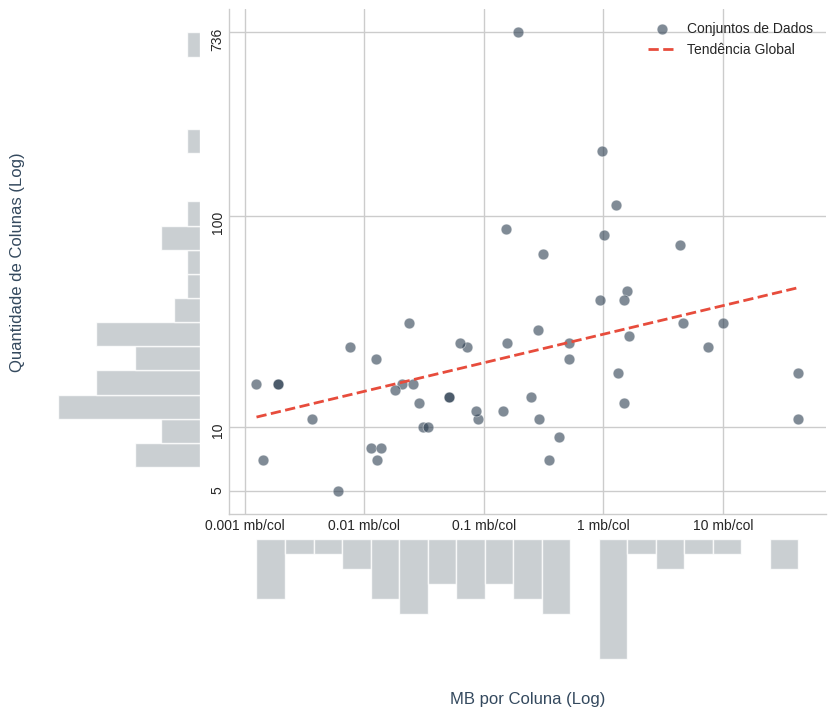

In [ ]:
df = df_PosDatasetsClean.copy()
df['Memory_Usage_MB'] = df['Memory_Usage_MB'].astype(str).str.replace(',', '.').astype(float)
df['Columns_Count'] = df['Columns_Count'].astype(float) 
df_clean = df[['Memory_Usage_MB', 'Columns_Count']].dropna()
df_clean = df_clean[(df_clean['Memory_Usage_MB'] > 0) & (df_clean['Columns_Count'] > 0)]
x = df_clean['Memory_Usage_MB'] / df_clean['Columns_Count']
y = df_clean['Columns_Count']
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(10, 8), facecolor='white')
gs = fig.add_gridspec(2, 2, width_ratios=(1, 4), height_ratios=(4, 1), wspace=0.08, hspace=0.08)
ax_main = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)
color_scatter = '#2c3e50' 
color_trend = '#e74c3c'    
color_hist = '#bdc3c7'     
ax_main.scatter(x, y, alpha=0.6, color=color_scatter, edgecolors='white', linewidth=0.5, s=60, label='Conjuntos de Dados')
ax_main.set_xscale('log')
ax_main.set_yscale('log')
log_x = np.log10(x)
log_y = np.log10(y)
z = np.polyfit(log_x, log_y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
ax_main.plot(x_sorted, 10**(p(np.log10(x_sorted))), color=color_trend, linewidth=2, linestyle='--', label='Tendência Global')
bins_x = np.logspace(np.log10(x.min()), np.log10(x.max()), 20)
bins_y = np.logspace(np.log10(y.min()), np.log10(y.max()), 20)
ax_left.hist(y, bins=bins_y, orientation='horizontal', color=color_hist, alpha=0.8)
ax_left.set_yscale('log')
ax_left.invert_xaxis()
ax_bottom.hist(x, bins=bins_x, color=color_hist, alpha=0.8)
ax_bottom.set_xscale('log')
ax_bottom.invert_yaxis()
min_y = y.min()
max_y = y.max()
min_power = int(np.ceil(np.log10(min_y)))
max_power = int(np.floor(np.log10(max_y)))
intermediarios = [10.0**i for i in range(min_power, max_power + 1)]
valores_desejados = [min_y] + intermediarios + [max_y]
novos_yticks = sorted(list(set(valores_desejados)))
ax_main.set_yticks(novos_yticks)
formatter_x = FuncFormatter(lambda val, pos: f"{val:g} mb/col")
formatter_y = FuncFormatter(lambda val, pos: f"{val:g}")
ax_main.xaxis.set_major_formatter(formatter_x)
ax_main.yaxis.set_major_formatter(formatter_y)
for ax in [ax_main, ax_left, ax_bottom]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
ax_left.spines['left'].set_visible(False)
ax_left.spines['bottom'].set_visible(False)
ax_bottom.spines['bottom'].set_visible(False)
ax_bottom.spines['left'].set_visible(False)
ax_left.grid(False)
ax_bottom.grid(False)
ax_left.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False) 
ax_bottom.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False) 
ax_main.tick_params(axis="y", left=True, labelleft=True, labelsize=10, labelrotation=90)
ax_main.tick_params(axis="x", bottom=True, labelbottom=True, labelsize=10)
ax_left.set_ylabel('Quantidade de Colunas (Log)', fontsize=12, color='#34495e', labelpad=15)
ax_bottom.set_xlabel('MB por Coluna (Log)', fontsize=12, color='#34495e', labelpad=15)
ax_main.legend(loc='upper right', frameon=False, fontsize=10)
fig.subplots_adjust(top=0.92, bottom=0.1) 
plt.show()

In [27]:
import pandas as pd
import numpy as np

# Preparação dos dados (mesma lógica do seu código)
df = df_PosDatasetsClean.copy()
df['Memory_Usage_MB'] = df['Memory_Usage_MB'].astype(str).str.replace(',', '.').astype(float)
df['Columns_Count'] = df['Columns_Count'].astype(float) 
df_clean = df[['Memory_Usage_MB', 'Columns_Count']].dropna()
df_clean = df_clean[(df_clean['Memory_Usage_MB'] > 0) & (df_clean['Columns_Count'] > 0)]

# Isolando a variável Y (Quantidade de Colunas)
y = df_clean['Columns_Count']

# Definindo os mesmos 20 bins logarítmicos usados no matplotlib
bins_y = np.logspace(np.log10(y.min()), np.log10(y.max()), 20)

# Calculando o histograma matematicamente
counts, edges = np.histogram(y, bins=bins_y)

# Imprimindo os resultados formatados no terminal
print("Distribuição da Quantidade de Colunas (Datasets por faixa de dimensionalidade):\n")
for i in range(len(counts)):
    faixa_inicio = edges[i]
    faixa_fim = edges[i+1]
    quantidade = counts[i]
    
    # Exibe apenas as faixas que possuem pelo menos 1 dataset para facilitar a leitura
    if quantidade > 0:
        print(f"Faixa de {faixa_inicio:6.1f} a {faixa_fim:6.1f} colunas: {quantidade:2d} dataset(s)")

# Calculando a concentração específica na faixa citada no texto (10 a 100)
datasets_10_100 = df_clean[(df_clean['Columns_Count'] >= 10) & (df_clean['Columns_Count'] <= 100)].shape[0]
total_datasets = df_clean.shape[0]
percentual = (datasets_10_100 / total_datasets) * 100

print(f"\nResumo para o texto:")
print(f"Total de datasets entre 10 e 100 colunas: {datasets_10_100} de {total_datasets} ({percentual:.1f}%)")

Distribuição da Quantidade de Colunas (Datasets por faixa de dimensionalidade):

Faixa de    6.5 a    8.5 colunas:  5 dataset(s)
Faixa de    8.5 a   11.0 colunas:  3 dataset(s)
Faixa de   11.0 a   14.3 colunas: 11 dataset(s)
Faixa de   14.3 a   18.6 colunas:  8 dataset(s)
Faixa de   18.6 a   24.2 colunas:  5 dataset(s)
Faixa de   24.2 a   31.5 colunas:  8 dataset(s)
Faixa de   31.5 a   40.9 colunas:  2 dataset(s)
Faixa de   40.9 a   53.2 colunas:  1 dataset(s)
Faixa de   53.2 a   69.2 colunas:  1 dataset(s)
Faixa de   69.2 a   90.0 colunas:  3 dataset(s)
Faixa de   90.0 a  117.0 colunas:  1 dataset(s)
Faixa de  197.9 a  257.3 colunas:  1 dataset(s)
Faixa de  565.9 a  736.0 colunas:  1 dataset(s)

Resumo para o texto:
Total de datasets entre 10 e 100 colunas: 41 de 51 (80.4%)


In [28]:
import pandas as pd
import numpy as np

# Preparação dos dados
df = df_PosDatasetsClean.copy()
df['Memory_Usage_MB'] = df['Memory_Usage_MB'].astype(str).str.replace(',', '.').astype(float)
df['Columns_Count'] = df['Columns_Count'].astype(float) 
df_clean = df[['Memory_Usage_MB', 'Columns_Count']].dropna()
df_clean = df_clean[(df_clean['Memory_Usage_MB'] > 0) & (df_clean['Columns_Count'] > 0)]

# Isolando a variável X (MB por Coluna)
x = df_clean['Memory_Usage_MB'] / df_clean['Columns_Count']

# Definindo os mesmos 20 bins logarítmicos usados no matplotlib para o eixo X
bins_x = np.logspace(np.log10(x.min()), np.log10(x.max()), 20)

# Calculando o histograma matematicamente
counts, edges = np.histogram(x, bins=bins_x)

# Imprimindo os resultados formatados no terminal
print("Distribuição de MB por Coluna (Datasets por faixa de tamanho):\n")
for i in range(len(counts)):
    faixa_inicio = edges[i]
    faixa_fim = edges[i+1]
    quantidade = counts[i]
    
    # Exibe apenas as faixas que possuem pelo menos 1 dataset
    if quantidade > 0:
        print(f"Faixa de {faixa_inicio:8.4f} a {faixa_fim:8.4f} mb/col: {quantidade:2d} dataset(s)")

# Identificando a faixa com a maior concentração absoluta (pico do histograma)
max_count_index = np.argmax(counts)
max_faixa_inicio = edges[max_count_index]
max_faixa_fim = edges[max_count_index+1]
max_quantidade = counts[max_count_index]
total_datasets = df_clean.shape[0]
percentual_max = (max_quantidade / total_datasets) * 100

# Calculando a concentração no 'entorno de 1 mb/col' (ex: entre 0.1 e 10 mb/col)
datasets_entorno_1 = df_clean[(x >= 0.1) & (x <= 10)].shape[0]
percentual_entorno = (datasets_entorno_1 / total_datasets) * 100

print(f"\nResumo para o texto:")
print(f"O pico de concentração está na faixa de {max_faixa_inicio:.4f} a {max_faixa_fim:.4f} mb/col, com {max_quantidade} datasets ({percentual_max:.1f}%).")
print(f"Total de datasets no entorno de 1 mb/col (entre 0.1 e 10 mb/col): {datasets_entorno_1} de {total_datasets} ({percentual_entorno:.1f}%).")

Distribuição de MB por Coluna (Datasets por faixa de tamanho):

Faixa de   0.0012 a   0.0022 mb/col:  4 dataset(s)
Faixa de   0.0022 a   0.0038 mb/col:  1 dataset(s)
Faixa de   0.0038 a   0.0065 mb/col:  1 dataset(s)
Faixa de   0.0065 a   0.0113 mb/col:  2 dataset(s)
Faixa de   0.0113 a   0.0195 mb/col:  4 dataset(s)
Faixa de   0.0195 a   0.0338 mb/col:  5 dataset(s)
Faixa de   0.0338 a   0.0585 mb/col:  3 dataset(s)
Faixa de   0.0585 a   0.1014 mb/col:  4 dataset(s)
Faixa de   0.1014 a   0.1757 mb/col:  3 dataset(s)
Faixa de   0.1757 a   0.3044 mb/col:  4 dataset(s)
Faixa de   0.3044 a   0.5273 mb/col:  5 dataset(s)
Faixa de   0.9136 a   1.5827 mb/col:  8 dataset(s)
Faixa de   1.5827 a   2.7419 mb/col:  1 dataset(s)
Faixa de   2.7419 a   4.7502 mb/col:  2 dataset(s)
Faixa de   4.7502 a   8.2293 mb/col:  1 dataset(s)
Faixa de   8.2293 a  14.2566 mb/col:  1 dataset(s)
Faixa de  24.6985 a  42.7882 mb/col:  2 dataset(s)

Resumo para o texto:
O pico de concentração está na faixa de 0.9136 

---

##### B ) Word Cloud Filtrado por Macro

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.colors as mcolors
import numpy as np

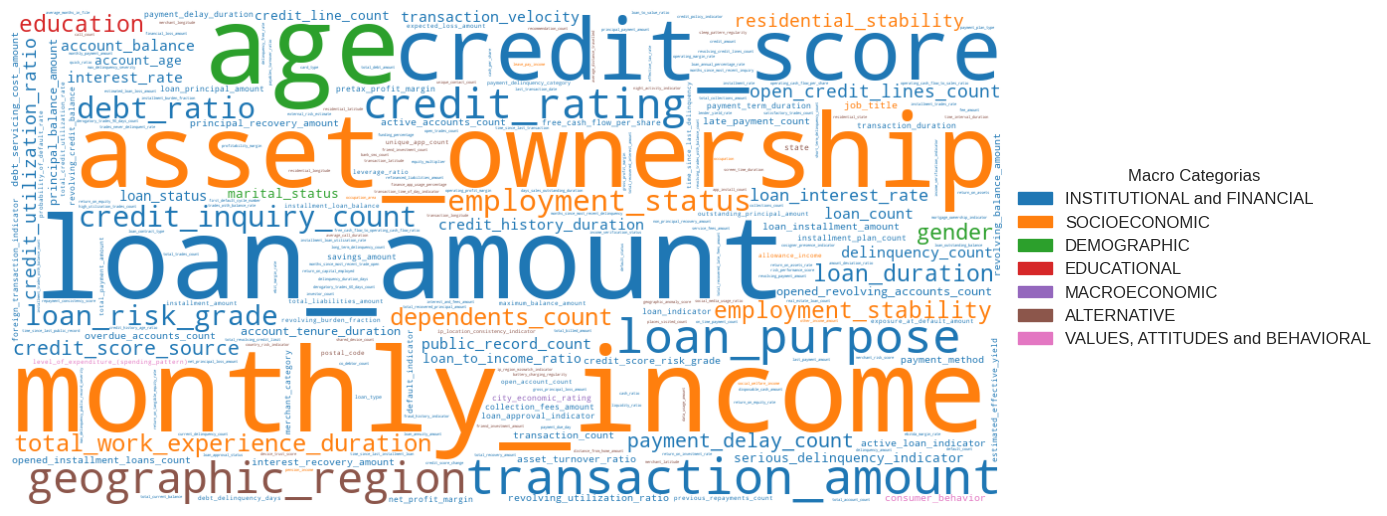

In [23]:
df = df_MicroTC.copy()
df = df.dropna(subset=['conceito_padronizado', 'macro_categoria'])
word_freq = df['conceito_padronizado'].value_counts().to_dict()
word_to_category = df.groupby('conceito_padronizado')['macro_categoria'].first().to_dict()
categories = df['macro_categoria'].unique()
cmap = plt.get_cmap('tab10')
category_colors = {cat: mcolors.to_hex(cmap(i % 10)) for i, cat in enumerate(categories)}
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    cat = word_to_category.get(word, categories[0])
    return category_colors.get(cat, "#000000")
wc = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    color_func=color_func,
    prefer_horizontal=0.9, 
    max_words=250,         
    random_state=42       
)
wc.generate_from_frequencies(word_freq)
plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off") # Esconde os eixos (números)
handles = [plt.Rectangle((0,0), 1, 1, color=category_colors[cat]) for cat in categories]
plt.legend(handles, 
           categories, 
           loc='center left', 
           bbox_to_anchor=(1, 0.5), 
           title="Macro Categorias", 
           fontsize='medium')
plt.tight_layout()
plt.show()

---

##### C ) Gráfico Imcompleto... 

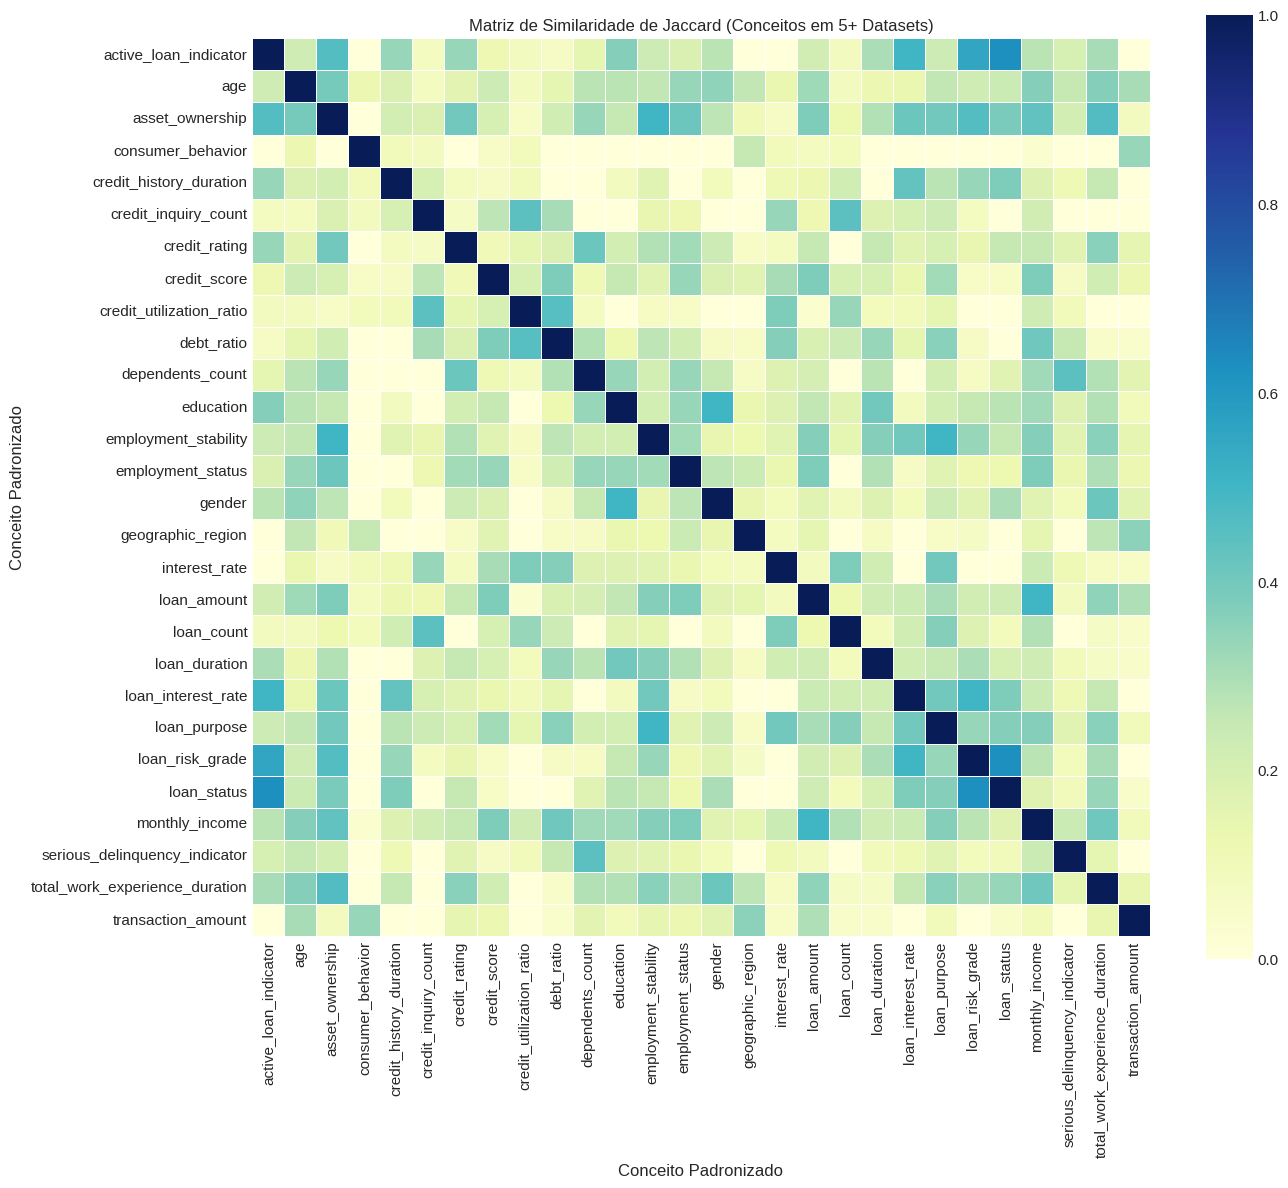

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregando os DataFrames

# 2. Fazendo o cruzamento (map)
df_merged = df_MacroTC.merge(df_MicroTC, left_on='Col', right_on='variavel_original', how='inner')

# 3. Removendo duplicatas
df_unique = df_merged[['id', 'conceito_padronizado']].drop_duplicates()

# 4. Filtro de Relevância e Esparsidade
# Exige que o conceito apareça em pelo menos 5 'ids' diferentes
contagem = df_unique['conceito_padronizado'].value_counts()
conceitos_validos = contagem[contagem >= 5].index
df_filtrado = df_unique[df_unique['conceito_padronizado'].isin(conceitos_validos)]

# 5. Criando a matriz binária de presença
pivot_df = df_filtrado.assign(val=1).pivot(index='id', columns='conceito_padronizado', values='val').fillna(0)

# 6. Cálculo Matemático
# Matriz de co-ocorrência pura (produto escalar)
co_occ = pivot_df.T.dot(pivot_df)

# Similaridade de Jaccard: J(A,B) = Co-occ / (Total A + Total B - Co-occ)
contagens_diagonais = np.diag(co_occ)
uniao = contagens_diagonais[:, None] + contagens_diagonais[None, :] - co_occ
matriz_jaccard = co_occ / uniao

# 7. Plotando o Gráfico (Heatmap)
plt.figure(figsize=(14, 12))
sns.heatmap(
    matriz_jaccard, 
    cmap='YlGnBu', # Paleta Amarelo (0) para Azul Escuro (1)
    center=0.5, 
    annot=False,     
    square=True, 
    linewidths=.5
)

plt.title("Matriz de Similaridade de Jaccard (Conceitos em 5+ Datasets)")
plt.xlabel("Conceito Padronizado")
plt.ylabel("Conceito Padronizado")
plt.tight_layout()
plt.show()

---

##### D ) Quantidade média das macro categorias por datasets com intervalo de confiança

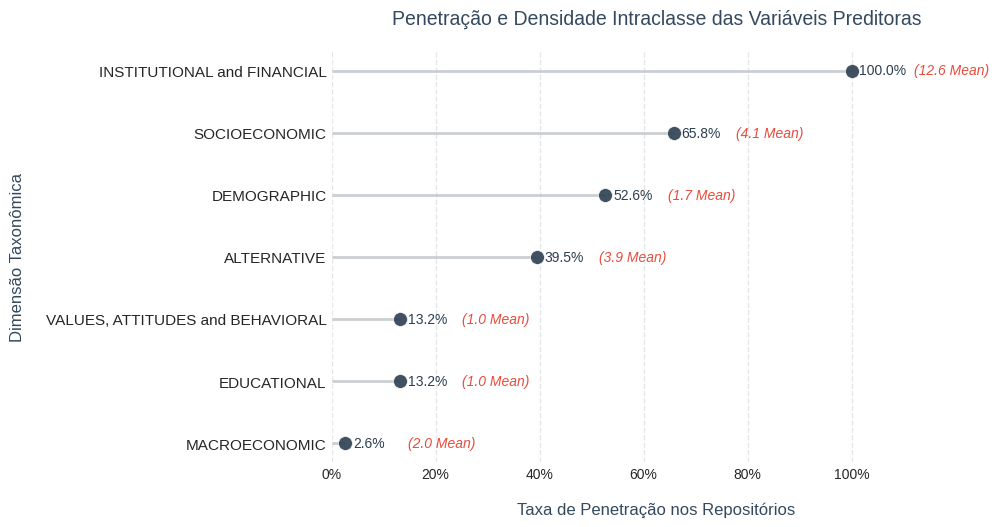

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Preparação dos dados
df_valid_macro = df_MacroTC[df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED'].copy()

# Matriz de contagem de variáveis por dataset (id) e categoria
df_crosstab = pd.crosstab(df_valid_macro['id'], df_valid_macro['Col_Standardized'])

# Taxa de Penetração (Presença % nos datasets)
df_presenca = (df_crosstab > 0).mean() * 100

# Densidade Intraclasse (Média condicional de colunas quando a categoria está presente)
df_media_condicional = df_crosstab.replace(0, np.nan).mean()

# Consolidando os dados em um DataFrame para o plot
df_plot = pd.DataFrame({
    'Macro_Categoria': df_presenca.index,
    'Percentual_Presenca': df_presenca.values,
    'Media_Variaveis': df_media_condicional.values
})

# Ordenando pelo percentual de presença para o efeito escada do pirulito
df_plot = df_plot.sort_values(by='Percentual_Presenca', ascending=True).reset_index(drop=True)

# 2. Configurações visuais espelhadas do gráfico A.1
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')

# Paleta de cores exata do A.1
color_scatter = '#2c3e50' 
color_trend = '#e74c3c'    
color_hist = '#bdc3c7'
color_text = '#34495e'

# 3. Criando o formato de pirulito (Lollipop)
# Linha do pirulito
ax.hlines(y=df_plot['Macro_Categoria'], xmin=0, xmax=df_plot['Percentual_Presenca'], 
          color=color_hist, alpha=0.8, linewidth=2)

# Marcador do pirulito
ax.plot(df_plot['Percentual_Presenca'], df_plot['Macro_Categoria'], "o", 
        markersize=10, color=color_scatter, alpha=0.9, markeredgecolor='white', markeredgewidth=0.5)

# 4. Adicionando os rótulos de dados (Penetração e Densidade)
for i in range(len(df_plot)):
    v_perc = df_plot['Percentual_Presenca'].iloc[i]
    v_med = df_plot['Media_Variaveis'].iloc[i]
    
    # Texto principal: Porcentagem de penetração
    ax.text(v_perc + 1.5, i, f'{v_perc:.1f}%', color=color_scatter, va='center', fontsize=10)
    
    # Texto secundário: Média de variáveis (Densidade Intraclasse) com a cor de destaque (trend)
    ax.text(v_perc + 12, i, f'({v_med:.1f} Mean)', color=color_trend, va='center', fontsize=10, style='italic')

# 5. Formatação dos eixos e remoção das bordas (Spines) idêntica ao A.1
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([0, 20, 40, 60, 80, 100])

# Configuração dos Ticks
ax.tick_params(axis="y", left=False, labelleft=True, labelsize=11)
ax.tick_params(axis="x", bottom=False, labelbottom=True, labelsize=10)

# Aplicando o formatador de porcentagem no eixo X
formatter_x = FuncFormatter(lambda val, pos: f"{val:g}%")
ax.xaxis.set_major_formatter(formatter_x)

# 6. Rótulos (Labels)
ax.set_xlabel('Taxa de Penetração nos Repositórios', fontsize=12, color=color_text, labelpad=15)
ax.set_ylabel('Dimensão Taxonômica', fontsize=12, color=color_text, labelpad=15)
ax.set_title('Penetração e Densidade Intraclasse das Variáveis Preditoras', fontsize=14, color=color_text, pad=20)

# Limites do eixo X ajustados para dar espaço às anotações de texto
ax.set_xlim(0, max(df_plot['Percentual_Presenca']) + 25)

# Grid apenas vertical para facilitar a leitura da porcentagem
ax.grid(axis='y', visible=False)
ax.grid(axis='x', color=color_hist, linestyle='--', alpha=0.4)

# Ajuste final de margens
fig.subplots_adjust(top=0.92, bottom=0.1, left=0.25) 
plt.show()

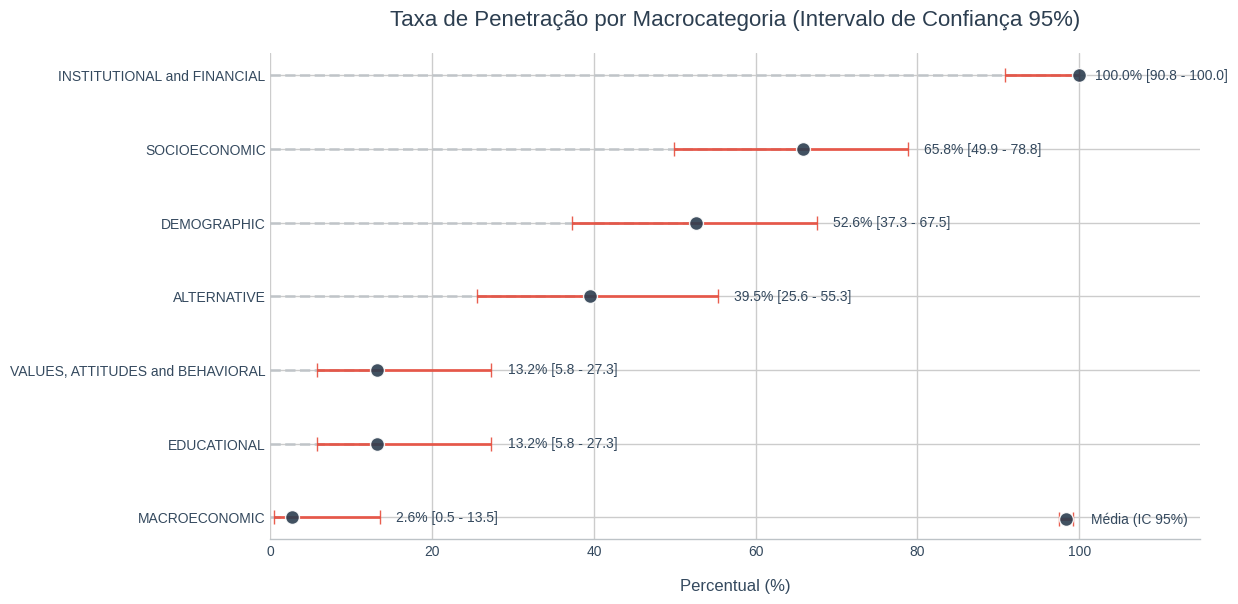

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportion_confint
df_valid_macro = df_MacroTC[df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED'].copy()
df_crosstab = pd.crosstab(df_valid_macro['id'], df_valid_macro['Col_Standardized']).fillna(0)
df_presenca_bin = (df_crosstab > 0).astype(int)
n_amostras = len(df_presenca_bin)
sucessos = df_presenca_bin.sum()
media_presenca = (sucessos / n_amostras) * 100
ci_lower, ci_upper = proportion_confint(sucessos, n_amostras, alpha=0.05, method='wilson')
ci_lower = ci_lower * 100
ci_upper = ci_upper * 100
df_estatisticas = pd.DataFrame({
    'Macro_Categoria': media_presenca.index,
    'Media_Presenca': media_presenca.values,
    'CI_Lower': ci_lower,
    'CI_Upper': ci_upper
})
df_estatisticas = df_estatisticas.sort_values(by='Media_Presenca', ascending=True).reset_index(drop=True)
erro_inferior = df_estatisticas['Media_Presenca'] - df_estatisticas['CI_Lower']
erro_superior = df_estatisticas['CI_Upper'] - df_estatisticas['Media_Presenca']
erros_assimetricos = [erro_inferior, erro_superior]
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
color_scatter = '#2c3e50' 
color_error = '#e74c3c'    
color_line = '#bdc3c7'
ax.hlines(y=df_estatisticas['Macro_Categoria'], xmin=0, xmax=df_estatisticas['Media_Presenca'], 
          color=color_line, alpha=0.8, linewidth=2, linestyles='--')
ax.errorbar(df_estatisticas['Media_Presenca'], df_estatisticas['Macro_Categoria'], 
            xerr=erros_assimetricos, 
            fmt='o', color=color_scatter, ecolor=color_error, alpha=0.9, markersize=10, 
            capsize=5, capthick=2, elinewidth=2, label='Média (IC 95%)',
            markeredgecolor='white', markeredgewidth=1)
for i, row in df_estatisticas.iterrows():
    texto = f"{row['Media_Presenca']:.1f}% [{row['CI_Lower']:.1f} - {row['CI_Upper']:.1f}]"
    offset = row['CI_Upper'] + 2
    ax.text(offset, i, texto, color='#34495e', va='center', fontsize=10)
ax.set_title('Taxa de Penetração por Macrocategoria (Intervalo de Confiança 95%)', fontsize=16, color='#2c3e50', pad=20)
ax.set_xlabel('Percentual (%)', fontsize=12, color='#34495e', labelpad=15)
ax.set_ylabel('')
ax.set_xlim(0, 115) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#bdc3c7')
ax.tick_params(axis="y", left=False, labelleft=True, labelsize=10, labelcolor='#34495e')
ax.tick_params(axis="x", bottom=True, labelbottom=True, labelsize=10, labelcolor='#34495e')
ax.legend(loc='lower right', frameon=False, fontsize=10, labelcolor='#34495e')
fig.subplots_adjust(top=0.92) 
plt.show()

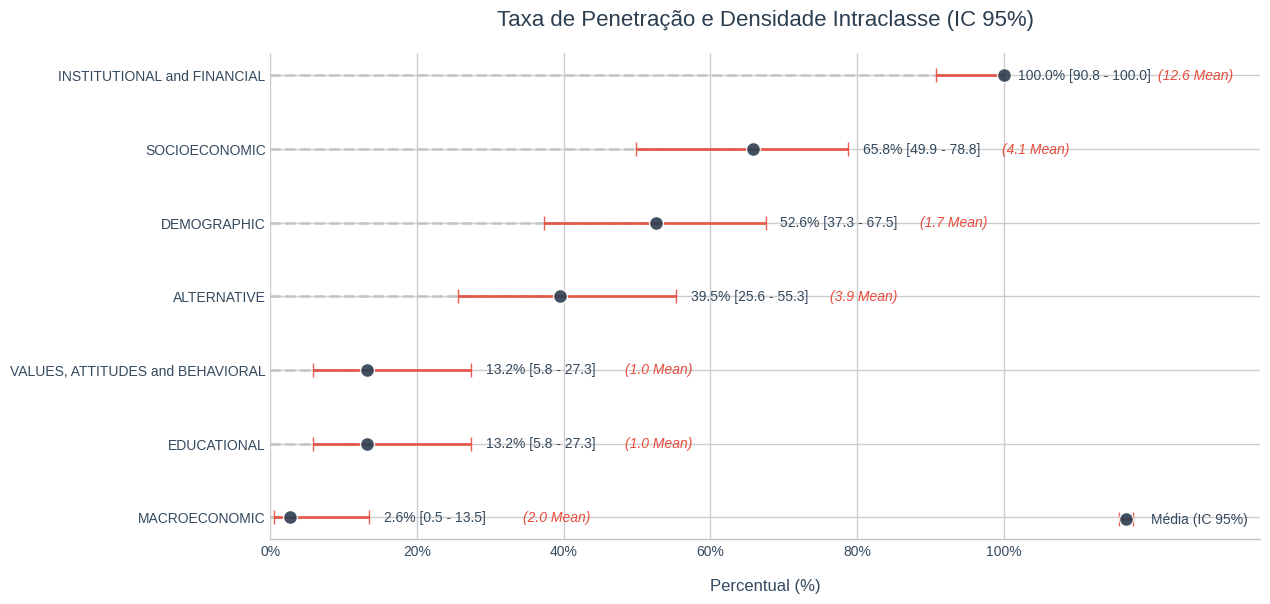

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportion_confint
from matplotlib.ticker import FuncFormatter

# 1. Preparação dos dados base
df_valid_macro = df_MacroTC[df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED'].copy()
df_crosstab = pd.crosstab(df_valid_macro['id'], df_valid_macro['Col_Standardized']).fillna(0)
df_presenca_bin = (df_crosstab > 0).astype(int)

# 2. Cálculos de Penetração e Intervalo de Confiança
n_amostras = len(df_presenca_bin)
sucessos = df_presenca_bin.sum()
media_presenca = (sucessos / n_amostras) * 100

ci_lower, ci_upper = proportion_confint(sucessos, n_amostras, alpha=0.05, method='wilson')
ci_lower = ci_lower * 100
ci_upper = ci_upper * 100

# 3. NOVO: Cálculo da Média Condicional (Densidade)
df_media_condicional = df_crosstab.replace(0, np.nan).mean()

# 4. Construção do DataFrame de Estatísticas
df_estatisticas = pd.DataFrame({
    'Macro_Categoria': media_presenca.index,
    'Media_Presenca': media_presenca.values,
    'CI_Lower': ci_lower,
    'CI_Upper': ci_upper,
    'Media_Variaveis': df_media_condicional.values # Adiciona a média condicional
})

# Ordenação para o gráfico
df_estatisticas = df_estatisticas.sort_values(by='Media_Presenca', ascending=True).reset_index(drop=True)

# 5. Cálculo das barras de erro
erro_inferior = df_estatisticas['Media_Presenca'] - df_estatisticas['CI_Lower']
erro_superior = df_estatisticas['CI_Upper'] - df_estatisticas['Media_Presenca']
erros_assimetricos = [erro_inferior, erro_superior]

# 6. Configurações Visuais e Plotagem
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

color_scatter = '#2c3e50' 
color_error = '#e74c3c'    
color_line = '#bdc3c7'

# Linha guia
ax.hlines(y=df_estatisticas['Macro_Categoria'], xmin=0, xmax=df_estatisticas['Media_Presenca'], 
          color=color_line, alpha=0.8, linewidth=2, linestyles='--')

# Barras de erro e marcadores
ax.errorbar(df_estatisticas['Media_Presenca'], df_estatisticas['Macro_Categoria'], 
            xerr=erros_assimetricos, 
            fmt='o', color=color_scatter, ecolor=color_error, alpha=0.9, markersize=10, 
            capsize=5, capthick=2, elinewidth=2, label='Média (IC 95%)',
            markeredgecolor='white', markeredgewidth=1)

# 7. Adicionando os Rótulos de Texto (IC e Média)
for i, row in df_estatisticas.iterrows():
    # Texto 1: Penetração e Intervalo de Confiança
    texto_ic = f"{row['Media_Presenca']:.1f}% [{row['CI_Lower']:.1f} - {row['CI_Upper']:.1f}]"
    offset_ic = row['CI_Upper'] + 2
    ax.text(offset_ic, i, texto_ic, color='#34495e', va='center', fontsize=10)
    
    # Texto 2: Média de Variáveis (Densidade)
    texto_media = f"({row['Media_Variaveis']:.1f} Mean)"
    offset_media = offset_ic + 19 # Afasta a média para não sobrepor o IC
    ax.text(offset_media, i, texto_media, color=color_error, va='center', fontsize=10, style='italic')

# 8. Formatação Final do Gráfico
ax.set_title('Taxa de Penetração e Densidade Intraclasse (IC 95%)', fontsize=16, color='#2c3e50', pad=20)
ax.set_xlabel('Percentual (%)', fontsize=12, color='#34495e', labelpad=15)
ax.set_ylabel('')

# Aumenta o limite para caber o novo texto sem cortar
ax.set_xlim(0, 135) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#bdc3c7')

ax.tick_params(axis="y", left=False, labelleft=True, labelsize=10, labelcolor='#34495e')
ax.tick_params(axis="x", bottom=True, labelbottom=True, labelsize=10, labelcolor='#34495e')

# NOVO: Trava os marcadores do eixo X para não exibir 120% ou mais
ax.set_xticks([0, 20, 40, 60, 80, 100])
formatter_x = FuncFormatter(lambda val, pos: f"{val:g}%")
ax.xaxis.set_major_formatter(formatter_x)

ax.legend(loc='lower right', frameon=False, fontsize=10, labelcolor='#34495e')
fig.subplots_adjust(top=0.92, right=0.95) 
plt.show()